**Gritap AMR By SSENOGA BADRU **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import seaborn as sns
import geopandas
from libpysal.weights import Queen
import geopandas as gpd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/gritapamrdatasets/amikacin/Amikacin_subset_clean.csv')

In [5]:
def subset_and_save_antibiotic_data(data, antibiotic_name):
    # Define the fixed set of columns
    base_columns = [
        'Isolate Id', 'Study', 'Species', 'Family', 'Country', 'State',
        'Gender', 'Age Group', 'Speciality', 'Source', 'In / Out Patient',
        'Year', 'Phenotype', 'AMPC', 'SHV', 'TEM', 'CTXM1', 'CTXM2', 'CTXM825',
        'CTXM9', 'VEB', 'PER', 'GES', 'ACC', 'CMY1MOX', 'CMY11', 'DHA', 'FOX',
        'ACTMIR', 'KPC', 'OXA', 'NDM', 'IMP', 'VIM', 'SPM', 'GIM'
    ]

    # Construct the full list of columns including the antibiotic columns
    antibiotic_columns = [antibiotic_name, f"{antibiotic_name}_I"]
    all_columns = base_columns + antibiotic_columns

    missing_columns = [col for col in all_columns if col not in data.columns]
    if missing_columns:
        print(f"Warning: The following columns were not found in the DataFrame: {missing_columns}")
        # Filter out missing columns to avoid errors, or you could raise an error
        all_columns = [col for col in all_columns if col in data.columns]
        if not all_columns:
             print("Error: No valid columns remaining to subset.")
             return


    # Subset the DataFrame
    subset_data = data[all_columns]

    # Define the output filename
    output_filename = f"{antibiotic_name}_subset.csv"

    # Save the subset data to a CSV file
    subset_data.to_csv(output_filename, index=False)

    print(f"Subset data saved to {output_filename}")

In [6]:
# Amikacin
subset_and_save_antibiotic_data(data, 'Amikacin')

Subset data saved to Amikacin_subset.csv


In [7]:
# Load and preprocess data
amo = pd.read_csv('/content/Amikacin_subset.csv')

In [8]:
amo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161065 entries, 0 to 161064
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Isolate Id        161065 non-null  int64 
 1   Study             161065 non-null  object
 2   Species           161065 non-null  object
 3   Family            161065 non-null  object
 4   Country           161065 non-null  object
 5   Gender            159298 non-null  object
 6   Age Group         161065 non-null  object
 7   Speciality        161065 non-null  object
 8   Source            161065 non-null  object
 9   In / Out Patient  110684 non-null  object
 10  Year              161065 non-null  int64 
 11  Phenotype         47510 non-null   object
 12  Amikacin          97377 non-null   object
 13  Amikacin_I        93692 non-null   object
dtypes: int64(2), object(12)
memory usage: 17.2+ MB


In [12]:
amo.columns

Index(['Isolate Id', 'Study', 'Species', 'Family', 'Country', 'Gender',
       'Age Group', 'Speciality', 'Source', 'In / Out Patient', 'Year',
       'Phenotype', 'Amikacin', 'Amikacin_I'],
      dtype='object')

In [13]:
# Columns of interest
columns_of_interest = ['Isolate Id', 'Study', 'Species', 'Family', 'Country',
       'Gender', 'Age Group', 'Speciality', 'Source', 'In / Out Patient',
       'Year', 'Phenotype', 'Amikacin', 'Amikacin_I']

# Get only columns of interest from the dataset
amo = amo[columns_of_interest].copy()

In [14]:
amo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128852 entries, 33506 to 90625
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Isolate Id        128852 non-null  int64 
 1   Study             128852 non-null  object
 2   Species           128852 non-null  object
 3   Family            128852 non-null  object
 4   Country           128852 non-null  object
 5   Gender            127435 non-null  object
 6   Age Group         128852 non-null  object
 7   Speciality        128852 non-null  object
 8   Source            128852 non-null  object
 9   In / Out Patient  88490 non-null   object
 10  Year              128852 non-null  int64 
 11  Phenotype         38001 non-null   object
 12  Amikacin          77952 non-null   object
 13  Amikacin_I        75003 non-null   object
dtypes: int64(2), object(12)
memory usage: 14.7+ MB


In [15]:
# Sample 80% of the data
amo = amo.sample(frac=0.8, random_state=42)

amo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103082 entries, 15459 to 7895
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Isolate Id        103082 non-null  int64 
 1   Study             103082 non-null  object
 2   Species           103082 non-null  object
 3   Family            103082 non-null  object
 4   Country           103082 non-null  object
 5   Gender            101928 non-null  object
 6   Age Group         103082 non-null  object
 7   Speciality        103082 non-null  object
 8   Source            103082 non-null  object
 9   In / Out Patient  70757 non-null   object
 10  Year              103082 non-null  int64 
 11  Phenotype         30256 non-null   object
 12  Amikacin          62375 non-null   object
 13  Amikacin_I        60015 non-null   object
dtypes: int64(2), object(12)
memory usage: 11.8+ MB


In [16]:
# Save data to file
amo.to_csv('Amikacin_subset_clean.csv', index=False)

In [18]:
# Define a function for cleaning and saving
def clean_and_save_data(data, antibiotic):
    # Columns of interest
    columns_of_interest = columns_of_interest = ['Isolate Id', 'Study', 'Species', 'Family', 'Country',
       'Gender', 'Age Group', 'Speciality', 'Source', 'In / Out Patient',
       'Year', 'Phenotype', antibiotic, f'{antibiotic}_I']
    data = data[columns_of_interest].copy()
    data = data.sample(frac=0.8, random_state=42)
    data.to_csv(f'{antibiotic}_subset_clean.csv', index=False)
    print(f"Data cleaned and saved!")

clean_and_save_data(amo, 'Amikacin')

Data cleaned and saved!


In [19]:
clean_and_save_data(amo, 'Amikacin')

Data cleaned and saved!


In [20]:
country_to_continent = {
    'France': 'Europe',
    'Spain': 'Europe',
    'Belgium': 'Europe',
    'Italy': 'Europe',
    'Germany': 'Europe',
    'Canada': 'North America',
    'Ireland': 'Europe',
    'Portugal': 'Europe',
    'Israel': 'Asia',
    'Greece': 'Europe',
    'China': 'Asia',
    'United Kingdom': 'Europe',
    'Kuwait': 'Asia',
    'Poland': 'Europe',
    'Switzerland': 'Europe',
    'Hungary': 'Europe',
    'Austria': 'Europe',
    'Colombia': 'South America',
    'Chile': 'South America',
    'Finland': 'Europe',
    'Australia': 'Oceania',
    'Mexico': 'North America',
    'Denmark': 'Europe',
    'Sweden': 'Europe',
    'Hong Kong': 'Asia',
    'Japan': 'Asia',
    'Croatia': 'Europe',
    'Malaysia': 'Asia',
    'Nigeria': 'Africa',
    'Kenya': 'Africa',
    'Czech Republic': 'Europe',
    'Netherlands': 'Europe',
    'Russia': 'Europe',
    'Romania': 'Europe',
    'Venezuela': 'South America',
    'Thailand': 'Asia',
    'Philippines': 'Asia',
    'Turkey': 'Asia',
    'Korea, South': 'Asia',
    'South Africa': 'Africa',
    'Argentina': 'South America',
    'Taiwan': 'Asia',
    'Brazil': 'South America',
    'Panama': 'North America',
    'Jordan': 'Asia',
    'Saudi Arabia': 'Asia',
    'Pakistan': 'Asia',
    'Guatemala': 'North America',
    'Morocco': 'Africa',
    'India': 'Asia',
    'Singapore': 'Asia',
    'Vietnam': 'Asia',
    'Latvia': 'Europe',
    'Lithuania': 'Europe',
    'Serbia': 'Europe',
    'Dominican Republic': 'North America',
    'Costa Rica': 'North America',
    'Ukraine': 'Europe',
    'Ivory Coast': 'Africa',
    'Lebanon': 'Asia',
    'New Zealand': 'Oceania',
    'Qatar': 'Asia',
    'Slovenia': 'Europe',
    'Cameroon': 'Africa',
    'Jamaica': 'North America',
    'Bulgaria': 'Europe',
    'Norway': 'Europe',
    'Honduras': 'North America',
    'Puerto Rico': 'North America',
    'Nicaragua': 'North America',
    'Slovak Republic': 'Europe',
    'Oman': 'Asia',
    'Malawi': 'Africa',
    'Ghana': 'Africa',
    'Uganda': 'Africa',
    'Namibia': 'Africa',
    'Indonesia': 'Asia',
    'Mauritius': 'Africa',
    'Estonia': 'Europe',
    'El Salvador': 'North America',
    'Tunisia': 'Africa',
    'Egypt': 'Africa'
}

In [21]:
amo['Continent'] = amo['Country'].map(country_to_continent)

# Statistical Analysis

In [22]:
df = amo.copy()

In [23]:
# Focus on Amikacin resistance
df['resistant'] = (df['Amikacin_I'] == 'Resistant').astype(int)
df['total'] = 1  # Each row is one isolate

In [24]:
# Aggregate by Country, Year, and optionally Species
agg_df = df.groupby(['Country', 'Year', 'Species']).agg({
    'resistant': 'sum',
    'total': 'count'
}).reset_index()

In [25]:
agg_df['Continent'] = agg_df['Country'].map(country_to_continent)

In [26]:
# Create index mappings for modeling
continents = agg_df['Continent'].unique()
continent_idx = {cont: i for i, cont in enumerate(continents)}
agg_df['continent_idx'] = agg_df['Continent'].map(continent_idx)

countries = agg_df['Country'].unique()
country_idx = {country: i for i, country in enumerate(countries)}
agg_df['country_idx'] = agg_df['Country'].map(country_idx)

In [27]:
# Handle missing data
agg_df = agg_df.dropna(subset=['Country', 'Year', 'resistant', 'total'])

In [28]:
# Centre the year
mean_year = agg_df['Year'].mean()
agg_df['year_centered'] = agg_df['Year'] - mean_year

In [29]:
# Prepare data
n_continents = len(continents)
n_countries = len(countries)
country_to_continent = np.array([continent_idx[agg_df[agg_df['Country'] == country]['Continent'].iloc[0]] for country in countries])

In [30]:
with pm.Model() as model:
    # Global hyperparameters
    mu_alpha_global = pm.Normal('mu_alpha_global', mu=0, sigma=1)
    sigma_alpha_global = pm.HalfNormal('sigma_alpha_global', sigma=1)
    mu_beta_global = pm.Normal('mu_beta_global', mu=0, sigma=1)
    sigma_beta_global = pm.HalfNormal('sigma_beta_global', sigma=1)

    # Continent-level parameters
    alpha_continent = pm.Normal('alpha_continent', mu=mu_alpha_global, sigma=sigma_alpha_global, shape=n_continents)
    beta_continent = pm.Normal('beta_continent', mu=mu_beta_global, sigma=sigma_beta_global, shape=n_continents)

    # Country-level parameters
    sigma_alpha_country = pm.HalfNormal('sigma_alpha_country', sigma=1)
    sigma_beta_country = pm.HalfNormal('sigma_beta_country', sigma=1)
    alpha_country = pm.Normal('alpha_country', mu=alpha_continent[country_to_continent], sigma=sigma_alpha_country, shape=n_countries)
    beta_country = pm.Normal('beta_country', mu=beta_continent[country_to_continent], sigma=sigma_beta_country, shape=n_countries)

    # Linear predictor
    linear_predictor = alpha_country[agg_df['country_idx']] + beta_country[agg_df['country_idx']] * agg_df['year_centered']

    # Resistance rate
    p = pm.math.sigmoid(linear_predictor)

    # Likelihood
    resistant_obs = pm.Binomial('resistant_obs', n=agg_df['total'], p=p, observed=agg_df['resistant'])

    # Sample from posterior
    trace = pm.sample(1000, tune=1000, chains=4, cores=4, return_inferencedata=True)

Output()

ERROR:pymc.stats.convergence:There were 498 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


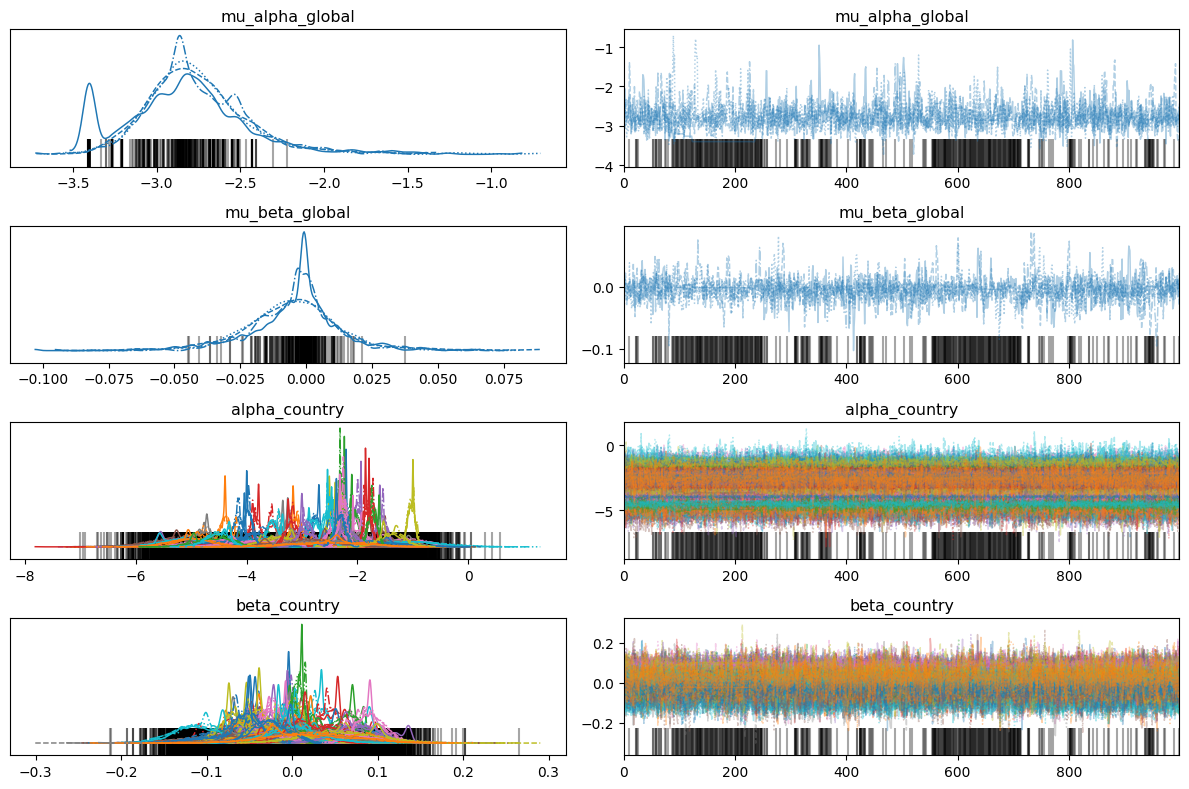

In [31]:
# Sampling and Convergence
az.plot_trace(trace, var_names=['mu_alpha_global', 'mu_beta_global', 'alpha_country', 'beta_country'])
plt.tight_layout()
# Save image of the Sampling result
plt.savefig('Amikacin_sampling_result.png')

In [32]:
# Get the summary DataFrame
summary_df = az.summary(trace, var_names=['alpha_country', 'beta_country'], hdi_prob=0.95)

# Create a mapping from index to country name
# We need the inverse of the country_idx dictionary
idx_to_country = {v: k for k, v in country_idx.items()}

# Extract the numerical index from the summary DataFrame index and map to country name
summary_df['Country'] = summary_df.index.map(lambda x: idx_to_country[int(x.split('[')[1].split(']')[0])])

# Reorder columns to put Country at the beginning
summary_df = summary_df[['Country'] + [col for col in summary_df.columns if col != 'Country']]

# Display the modified summary DataFrame
display(summary_df)

,Country,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_country[0],Argentina,-2.206,0.074,-2.362,-2.073,0.003,0.001,462.0,2306.0,1.03
alpha_country[1],Australia,-4.932,0.242,-5.403,-4.469,0.009,0.005,813.0,1055.0,1.01
alpha_country[2],Austria,-3.798,0.309,-4.387,-3.221,0.014,0.005,499.0,1826.0,1.01
alpha_country[3],Belgium,-3.847,0.109,-4.059,-3.632,0.002,0.002,2824.0,2760.0,1.01
alpha_country[4],Brazil,-2.001,0.072,-2.150,-1.869,0.002,0.001,1009.0,2030.0,1.01
...,...,...,...,...,...,...,...,...,...,...
beta_country[77],Uganda,0.012,0.052,-0.102,0.108,0.001,0.001,1949.0,1991.0,1.02
beta_country[78],Ukraine,0.059,0.044,-0.028,0.144,0.001,0.001,1009.0,2048.0,1.01
beta_country[79],United Kingdom,0.003,0.033,-0.062,0.069,0.001,0.001,2420.0,1969.0,1.01
beta_country[80],Venezuela,-0.025,0.021,-0.063,0.015,0.002,0.000,199.0,2375.0,1.02


### 1. Trends and Patterns over time

In [33]:
beta_summary = az.summary(trace, var_names=['beta_country'], hdi_prob=0.95)
beta_summary.index = countries  # Map indices to country names
beta_summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Argentina,-0.005,0.012,-0.027,0.020,0.000,0.000,2338.0,2695.0,1.03
Australia,0.004,0.038,-0.070,0.078,0.001,0.001,1770.0,2302.0,1.01
Austria,-0.028,0.043,-0.109,0.060,0.001,0.001,1071.0,2416.0,1.01
Belgium,-0.065,0.022,-0.111,-0.025,0.003,0.001,77.0,46.0,1.04
Brazil,0.000,0.014,-0.028,0.028,0.000,0.000,2548.0,2481.0,1.01
...,...,...,...,...,...,...,...,...,...
Uganda,0.012,0.052,-0.102,0.108,0.001,0.001,1949.0,1991.0,1.02
Ukraine,0.059,0.044,-0.028,0.144,0.001,0.001,1009.0,2048.0,1.01
United Kingdom,0.003,0.033,-0.062,0.069,0.001,0.001,2420.0,1969.0,1.01
Venezuela,-0.025,0.021,-0.063,0.015,0.002,0.000,199.0,2375.0,1.02


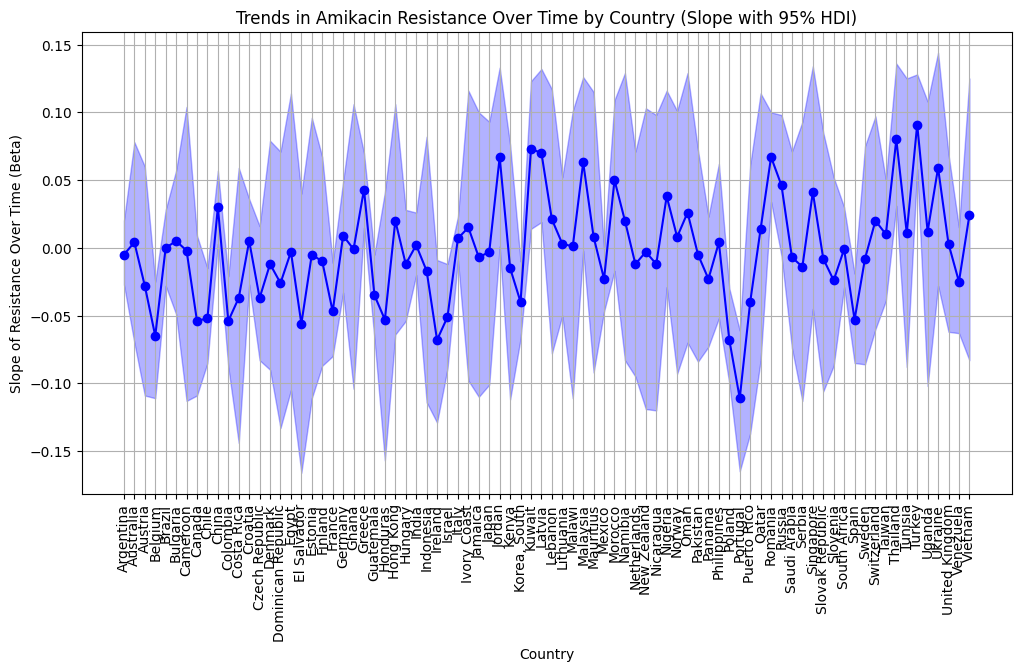

In [34]:
# Visualize trends
plt.figure(figsize=(12, 6))
plt.plot(beta_summary['mean'], marker='o', linestyle='-', color='b')
plt.fill_between(beta_summary.index,
                 beta_summary['hdi_2.5%'],
                 beta_summary['hdi_97.5%'],
                 color='b', alpha=0.3)

plt.xlabel('Country')
plt.ylabel('Slope of Resistance Over Time (Beta)')
plt.title('Trends in Amikacin Resistance Over Time by Country (Slope with 95% HDI)')
plt.xticks(rotation=90)
plt.grid(True)
# Save image of the Sampling result
plt.savefig('Amikacin_trend_pattern.png')
plt.show()
